<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/MACD/MACD_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install mplfinance if not already installed
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 4.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import yfinance as yf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import mplfinance as mpf
from matplotlib.lines import Line2D

In [9]:

# These are Google Drive file IDs. To get your own, right-click on the file in Google Drive, select 'Share', then 'Get link'. The ID is the part of the URL after 'id='.
OptionVolume_id = '1OGdLINK3zjlx6-lMq86SVq9TkbcglkeI'
OptionVolume = f'https://drive.google.com/uc?export=download&id={OptionVolume_id}'

OptionVolume200_id = '1gcwD510l4GFGNcKsbExR3GvKnDZwCHy4'
OptionVolume200 = f'https://drive.google.com/uc?export=download&id={OptionVolume200_id}'

In [10]:
df_option_volume = pd.read_csv(OptionVolume)
print("OptionVolume DataFrame head:")
display(df_option_volume.head())

OptionVolume DataFrame head:


,Symbol,Name,Price,Pct Chg,Trade Count,Total $ Notional,90-Day Avg $ Notional,Relative Notional to 90-Day Avg,Call $ Notional,Put $ Notional,Pct Single-Leg,Pct Multi-Leg,Pct Contingent,rank_notional
0,SPY,State Street SPDR S&P 500 ETF Trust,720.65,0.003,"1,152,523",2.62 B,2.57 B,1.02,1.48 B,1.15 B,82%,18%,NaN,400.0
1,TSLA,Tesla,390.82,0.024,"852,714",2.05 B,1.94 B,1.06,1.49 B,559.41 M,89%,11%,NaN,398.0
2,QQQ,Invesco QQQ Trust,674.15,0.01,"730,300",2.01 B,1.62 B,1.24,1.22 B,788.95 M,81%,18%,NaN,396.0
3,NVDA,Nvidia,198.45,-0.60%,"435,940",993.69 M,1.06 B,0.94,716.89 M,276.79 M,84%,15%,NaN,393.0
4,MSFT,Microsoft,414.44,0.016,"184,993",428.19 M,1.09 B,0.39,319.0 M,109.19 M,80%,19%,1%,389.0


### MACD Signal Line Crosses Analysis

In [18]:
# MACD Signal Line Crosses Analysis

START_DATE_ANALYSIS = "2020-01-01"

# Define MACD parameters (ensuring they are available here)
MACD_FAST_LENGTH = 12
MACD_SLOW_LENGTH = 26
MACD_SIGNAL_LENGTH = 9

# Dictionary to store df_analysis for each symbol
all_symbols_analysis_dfs = {}

# Iterate through each symbol in the OptionVolume DataFrame
for symbol in symbols_to_chart:
    print(f"\n--- Analyzing MACD Signal Line Crosses for {symbol} ---")

    # Fetch data from 2020-01-01 for the current symbol
    try:
        df_analysis = yf.download(symbol, start=START_DATE_ANALYSIS, end=datetime.now(), progress=False, auto_adjust=True)
        if df_analysis.empty:
            print(f"No data fetched for {symbol} from {START_DATE_ANALYSIS}, skipping.")
            continue
        if isinstance(df_analysis.columns, pd.MultiIndex):
            df_analysis.columns = df_analysis.columns.get_level_values(0)

        # Recalculate MACD for the extended dataset of the current symbol
        df_analysis['EMA_Fast'] = df_analysis['Close'].ewm(span=MACD_FAST_LENGTH, adjust=False).mean()
        df_analysis['EMA_Slow'] = df_analysis['Close'].ewm(span=MACD_SLOW_LENGTH, adjust=False).mean()
        df_analysis['MACD_Line'] = df_analysis['EMA_Fast'] - df_analysis['EMA_Slow']
        df_analysis['Signal_Line'] = df_analysis['MACD_Line'].ewm(span=MACD_SIGNAL_LENGTH, adjust=False).mean()
        df_analysis['MACD_Hist'] = df_analysis['MACD_Line'] - df_analysis['Signal_Line']

        # Calculate 5-day future return
        df_analysis['Future_5D_Return'] = df_analysis['Close'].pct_change(5).shift(-5)

    except Exception as e:
        print(f"Error fetching data or calculating MACD for {symbol}: {e}, skipping.")
        continue

    if not df_analysis.empty:
        print(f"Data loaded and MACD calculated for {symbol} from {START_DATE_ANALYSIS} to {df_analysis.index.max().strftime('%Y-%m-%d')}")
        # Store the processed DataFrame
        all_symbols_analysis_dfs[symbol] = df_analysis
    else:
        print(f"Could not load data for analysis for {symbol}.")

print(f"\nProcessed MACD analysis for {len(all_symbols_analysis_dfs)} symbols.")


--- Analyzing MACD Signal Line Crosses for SPY ---
Data loaded and MACD calculated for SPY from 2020-01-01 to 2026-06-01

--- Analyzing MACD Signal Line Crosses for TSLA ---
Data loaded and MACD calculated for TSLA from 2020-01-01 to 2026-06-01

--- Analyzing MACD Signal Line Crosses for QQQ ---
Data loaded and MACD calculated for QQQ from 2020-01-01 to 2026-06-01

--- Analyzing MACD Signal Line Crosses for NVDA ---
Data loaded and MACD calculated for NVDA from 2020-01-01 to 2026-06-01

--- Analyzing MACD Signal Line Crosses for MSFT ---
Data loaded and MACD calculated for MSFT from 2020-01-01 to 2026-06-01

--- Analyzing MACD Signal Line Crosses for MU ---
Data loaded and MACD calculated for MU from 2020-01-01 to 2026-06-01

--- Analyzing MACD Signal Line Crosses for META ---
Data loaded and MACD calculated for META from 2020-01-01 to 2026-06-01

--- Analyzing MACD Signal Line Crosses for AMZN ---
Data loaded and MACD calculated for AMZN from 2020-01-01 to 2026-06-01

--- Analyzing M

In [19]:
# Identify MACD Signal line crosses for all symbols

all_crosses_data = []

for symbol, df_analysis in all_symbols_analysis_dfs.items():
    # A cross occurs when MACD_Line crosses above or below Signal_Line
    # We look for the day *after* the actual crossover

    df_analysis['MACD_Cross_Above'] = (df_analysis['MACD_Line'].shift(1) < df_analysis['Signal_Line'].shift(1)) & \
                                      (df_analysis['MACD_Line'] > df_analysis['Signal_Line'])
    df_analysis['MACD_Cross_Below'] = (df_analysis['MACD_Line'].shift(1) > df_analysis['Signal_Line'].shift(1)) & \
                                      (df_analysis['MACD_Line'] < df_analysis['Signal_Line'])

    crosses = df_analysis[df_analysis['MACD_Cross_Above'] | df_analysis['MACD_Cross_Below']].copy()

    # Catalog crosses
    for index, row in crosses.iterrows():
        histogram_direction = None
        if row['MACD_Cross_Above']:
            histogram_direction = "Negative to Positive"
        elif row['MACD_Cross_Below']:
            histogram_direction = "Positive to Negative"

        if histogram_direction:
            all_crosses_data.append({
                'Symbol': symbol,
                'Date': index,
                'MACD_Value_at_Cross': row['MACD_Line'],
                'Signal_Value_at_Cross': row['Signal_Line'],
                'Histogram_Direction': histogram_direction,
                'Future_5D_Return': row['Future_5D_Return'] * 100 # Convert to percentage
            })

if all_crosses_data:
    crosses_df = pd.DataFrame(all_crosses_data)
    print(f"Found {len(crosses_df)} MACD Signal line crosses across all symbols.")
    display(crosses_df.head())
else:
    print("No MACD Signal line crosses found across all symbols.")

Found 11695 MACD Signal line crosses across all symbols.


,Symbol,Date,MACD_Value_at_Cross,Signal_Value_at_Cross,Histogram_Direction,Future_5D_Return
0,SPY,2020-01-09,-0.078660,-0.140970,Negative to Positive,1.307222
1,SPY,2020-01-27,0.967284,1.060307,Positive to Negative,0.191661
2,SPY,2020-02-05,0.531677,0.474445,Negative to Positive,1.370006
3,SPY,2020-02-24,1.262080,1.982276,Positive to Negative,-4.134359
4,SPY,2020-03-26,-17.385009,-18.015881,Negative to Positive,-3.587297


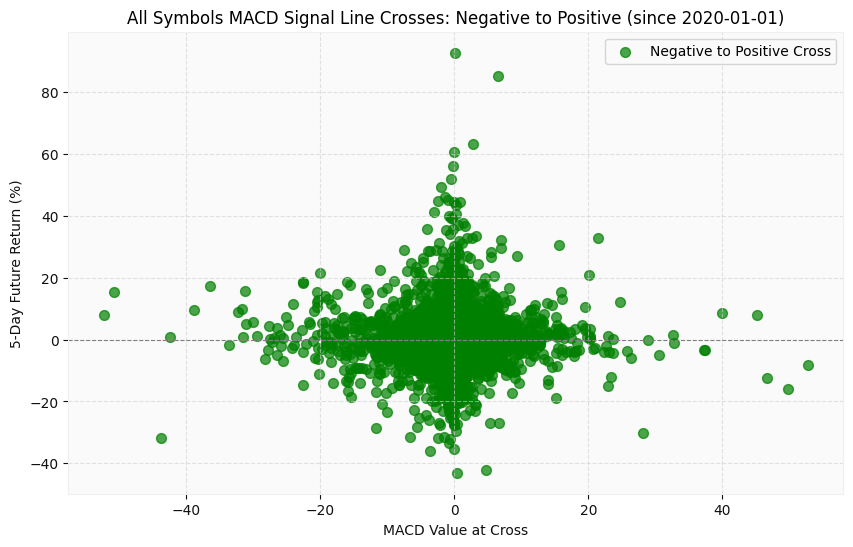

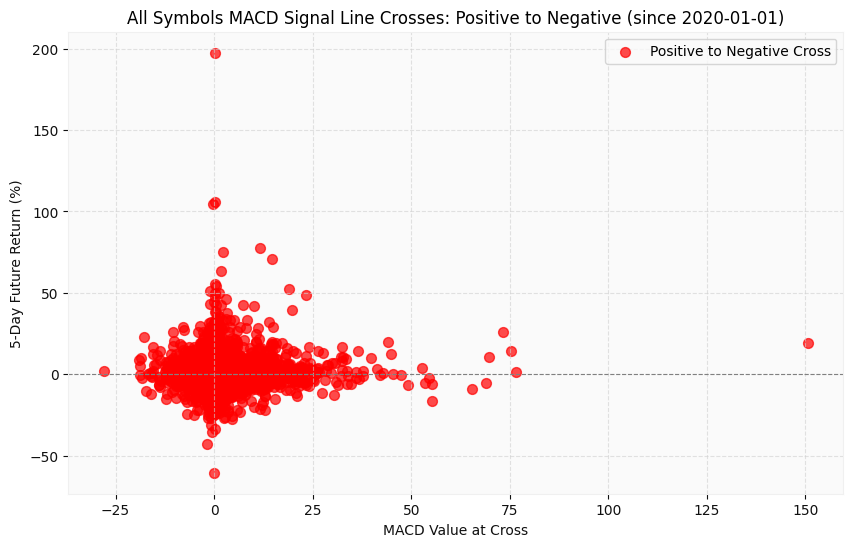

In [20]:
# Generate Scatter Plots

if 'crosses_df' in locals() and not crosses_df.empty:
    df_neg_to_pos = crosses_df[crosses_df['Histogram_Direction'] == 'Negative to Positive']
    df_pos_to_neg = crosses_df[crosses_df['Histogram_Direction'] == 'Positive to Negative']

    # Chart 1: Negative to Positive Crosses
    if not df_neg_to_pos.empty:
        plt.figure(figsize=(10, 6))
        plt.scatter(df_neg_to_pos['MACD_Value_at_Cross'],
                    df_neg_to_pos['Future_5D_Return'],
                    color='green', label='Negative to Positive Cross',
                    alpha=0.7, s=50)
        plt.title(f'All Symbols MACD Signal Line Crosses: Negative to Positive (since {START_DATE_ANALYSIS})')
        plt.xlabel('MACD Value at Cross')
        plt.ylabel('5-Day Future Return (%)')
        plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Zero line for returns
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.show()
    else:
        print("No Negative to Positive crosses data available to plot.")

    # Chart 2: Positive to Negative Crosses
    if not df_pos_to_neg.empty:
        plt.figure(figsize=(10, 6))
        plt.scatter(df_pos_to_neg['MACD_Value_at_Cross'],
                    df_pos_to_neg['Future_5D_Return'],
                    color='red', label='Positive to Negative Cross',
                    alpha=0.7, s=50)
        plt.title(f'All Symbols MACD Signal Line Crosses: Positive to Negative (since {START_DATE_ANALYSIS})')
        plt.xlabel('MACD Value at Cross')
        plt.ylabel('5-Day Future Return (%)')
        plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Zero line for returns
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.show()
    else:
        print("No Positive to Negative crosses data available to plot.")
else:
    print("No cross data available to plot scatter charts.")

### MACD Signal Line Crosses: Win Rate Heatmap

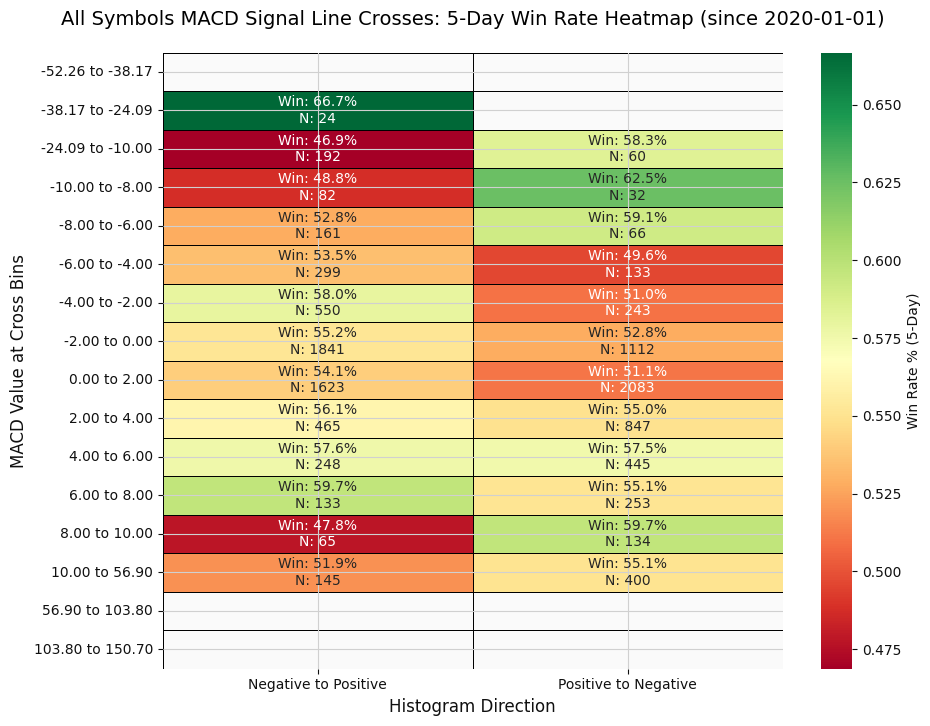

In [24]:
#MACD Signal Line Crosses: Win Rate Heatmap

# Ensure crosses_df exists and is not empty
if 'crosses_df' in locals() and not crosses_df.empty:
    # Create bins for MACD_Value_at_Cross to categorize the data
    min_macd_val = crosses_df['MACD_Value_at_Cross'].min()
    max_macd_val = crosses_df['MACD_Value_at_Cross'].max()

    # Define the core fine-grained range around zero
    fine_range_lower = -10.0
    fine_range_upper = 10.0
    fine_step = 2.0

    # Create fine bins around zero
    fine_bins = np.arange(fine_range_lower, fine_range_upper + fine_step, fine_step)

    # Create broader bins for the lower extreme
    num_broad_lower_bins = 3
    if min_macd_val < fine_range_lower:
        broad_lower_bins = np.linspace(min_macd_val, fine_range_lower, num_broad_lower_bins + 1)
    else:
        broad_lower_bins = np.array([min_macd_val]) # If min is within or above fine range, just use min_macd_val as a boundary

    # Create broader bins for the upper extreme
    num_broad_upper_bins = 3
    if max_macd_val > fine_range_upper:
        broad_upper_bins = np.linspace(fine_range_upper, max_macd_val, num_broad_upper_bins + 1)
    else:
        broad_upper_bins = np.array([max_macd_val]) # If max is within or below fine range, just use max_macd_val as a boundary

    # Combine all bin edges and sort them, removing duplicates
    bins = np.unique(np.concatenate([broad_lower_bins, fine_bins, broad_upper_bins]))

    # Ensure bins cover the entire range from min_macd_val to max_macd_val if not already covered
    if bins[0] > min_macd_val: bins = np.concatenate([[min_macd_val], bins])
    if bins[-1] < max_macd_val: bins = np.concatenate([bins, [max_macd_val]])

    # Adjust labels to cover the exact ranges for display
    labels = [f'{bins[i]:.2f} to {bins[i+1]:.2f}' for i in range(len(bins)-1)]

    # Create a CategoricalDtype to ensure all bins are considered even if empty
    all_bins_categories = pd.CategoricalDtype(categories=labels, ordered=True)

    crosses_df['MACD_Value_Bin'] = pd.cut(crosses_df['MACD_Value_at_Cross'], bins=bins, labels=labels, include_lowest=True)

    # Calculate win rate for each bin and histogram direction
    win_rate_analysis = crosses_df.groupby(['Histogram_Direction', 'MACD_Value_Bin'], observed=False).agg(
        Win_Rate=('Future_5D_Return', lambda x: (x > 0).mean()),
        Trade_Count=('Future_5D_Return', 'count')
    ).reset_index()

    # Filter out bins with very few trades to avoid misleading win rates
    win_rate_analysis = win_rate_analysis[win_rate_analysis['Trade_Count'] >= 10] # Threshold for minimum trades per bin

    if not win_rate_analysis.empty:
        # Pivot the table for heatmap
        heatmap_win_rate = win_rate_analysis.pivot_table(
            index='MACD_Value_Bin',
            columns='Histogram_Direction',
            values='Win_Rate',
            observed=False
        ).reindex(all_bins_categories.categories) # Reindex to ensure all categories are present

        # Pivot the trade count for annotation
        heatmap_trade_count = win_rate_analysis.pivot_table(
            index='MACD_Value_Bin',
            columns='Histogram_Direction',
            values='Trade_Count',
            observed=False
        ).reindex(all_bins_categories.categories) # Reindex to ensure all categories are present

        # Create a custom annotation DataFrame by combining win rate and trade count
        annotations = heatmap_win_rate.apply(
            lambda x: x.index.map(lambda y:
                f"Win: {heatmap_win_rate.loc[y, x.name]:.1%}\nN: {heatmap_trade_count.loc[y, x.name]:.0f}"
                if pd.notna(heatmap_win_rate.loc[y, x.name]) and pd.notna(heatmap_trade_count.loc[y, x.name])
                else ''
            ),
            axis=0
        )

        # Plot the heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            heatmap_win_rate,
            annot=annotations,    # Use the custom annotations
            fmt="",               # No automatic formatting, as annotations are already formatted
            cmap="RdYlGn", # Green for higher win rates, Red for lower
            linewidths=.5, # Add lines between cells
            linecolor='black',
            cbar_kws={'label': 'Win Rate % (5-Day)'}
        )
        plt.title(f'All Symbols MACD Signal Line Crosses: 5-Day Win Rate Heatmap (since {START_DATE_ANALYSIS})', fontsize=14, pad=20)
        plt.xlabel('Histogram Direction', fontsize=12)
        plt.ylabel('MACD Value at Cross Bins', fontsize=12)
        plt.yticks(rotation=0) # Ensure MACD bin labels are horizontal
        plt.show()
    else:
        print("Not enough data after filtering to generate win rate heatmap.")
else:
    print("No cross data available to generate win rate heatmap.")

## Average Return Heatmaps

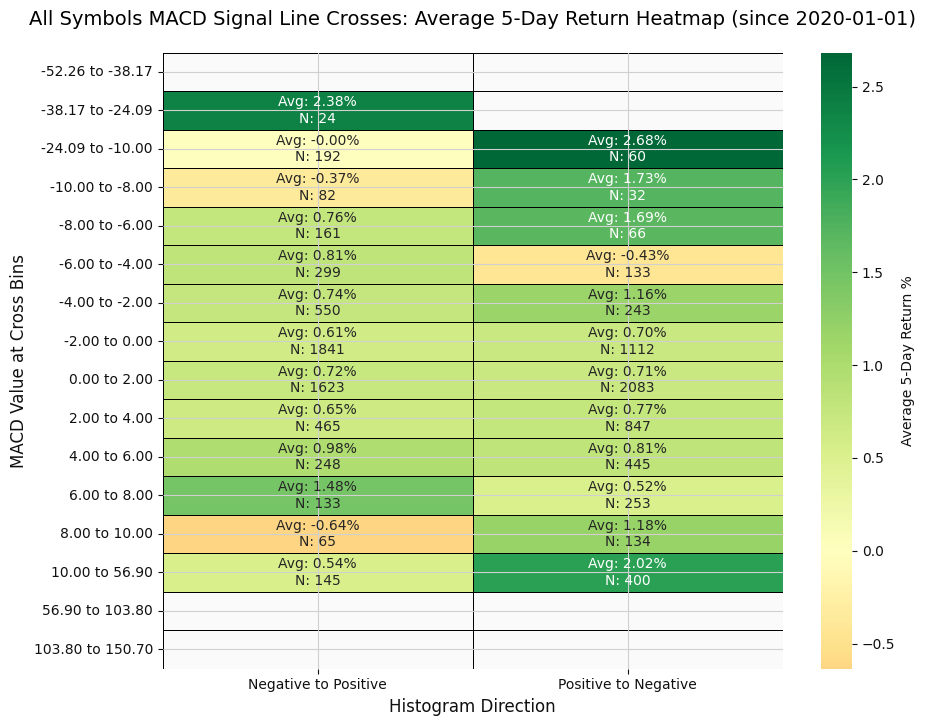

In [25]:
# Average Return Heatmaps

# Ensure crosses_df exists and is not empty
if 'crosses_df' in locals() and not crosses_df.empty:
    # Create bins for MACD_Value_at_Cross to categorize the data
    min_macd_val = crosses_df['MACD_Value_at_Cross'].min()
    max_macd_val = crosses_df['MACD_Value_at_Cross'].max()

    # Define the core fine-grained range around zero
    fine_range_lower = -10.0
    fine_range_upper = 10.0
    fine_step = 2.0

    # Create fine bins around zero
    fine_bins = np.arange(fine_range_lower, fine_range_upper + fine_step, fine_step)

    # Create broader bins for the lower extreme
    num_broad_lower_bins = 3
    if min_macd_val < fine_range_lower:
        broad_lower_bins = np.linspace(min_macd_val, fine_range_lower, num_broad_lower_bins + 1)
    else:
        broad_lower_bins = np.array([min_macd_val]) # If min is within or above fine range, just use min_macd_val as a boundary

    # Create broader bins for the upper extreme
    num_broad_upper_bins = 3
    if max_macd_val > fine_range_upper:
        broad_upper_bins = np.linspace(fine_range_upper, max_macd_val, num_broad_upper_bins + 1)
    else:
        broad_upper_bins = np.array([max_macd_val]) # If max is within or below fine range, just use max_macd_val as a boundary

    # Combine all bin edges and sort them, removing duplicates
    bins = np.unique(np.concatenate([broad_lower_bins, fine_bins, broad_upper_bins]))

    # Ensure bins cover the entire range from min_macd_val to max_macd_val if not already covered
    if bins[0] > min_macd_val: bins = np.concatenate([[min_macd_val], bins])
    if bins[-1] < max_macd_val: bins = np.concatenate([bins, [max_macd_val]])

    # Adjust labels to cover the exact ranges for display
    labels = [f'{bins[i]:.2f} to {bins[i+1]:.2f}' for i in range(len(bins)-1)]

    # Create a CategoricalDtype to ensure all bins are considered even if empty
    all_bins_categories = pd.CategoricalDtype(categories=labels, ordered=True)

    crosses_df['MACD_Value_Bin'] = pd.cut(crosses_df['MACD_Value_at_Cross'], bins=bins, labels=labels, include_lowest=True)

    # Calculate average 5-day return for each bin and histogram direction
    avg_return_analysis = crosses_df.groupby(['Histogram_Direction', 'MACD_Value_Bin'], observed=False).agg(
        Average_5D_Return=('Future_5D_Return', 'mean'),
        Trade_Count=('Future_5D_Return', 'count')
    ).reset_index()

    # Filter out bins with very few trades to avoid misleading averages
    avg_return_analysis = avg_return_analysis[avg_return_analysis['Trade_Count'] >= 10] # Threshold for minimum trades per bin

    if not avg_return_analysis.empty:
        # Pivot the table for heatmap
        heatmap_data_avg = avg_return_analysis.pivot_table(
            index='MACD_Value_Bin',
            columns='Histogram_Direction',
            values='Average_5D_Return',
            observed=False
        ).reindex(all_bins_categories.categories) # Reindex to ensure all categories are present

        # Pivot the trade count for annotation
        heatmap_trade_count = avg_return_analysis.pivot_table(
            index='MACD_Value_Bin',
            columns='Histogram_Direction',
            values='Trade_Count',
            observed=False
        ).reindex(all_bins_categories.categories) # Reindex to ensure all categories are present

        # Create a custom annotation DataFrame by combining average return and trade count
        annotations_avg_return = heatmap_data_avg.apply(
            lambda x: x.index.map(lambda y:
                f"Avg: {heatmap_data_avg.loc[y, x.name]:.2f}%\nN: {heatmap_trade_count.loc[y, x.name]:.0f}"
                if pd.notna(heatmap_data_avg.loc[y, x.name]) and pd.notna(heatmap_trade_count.loc[y, x.name])
                else ''
            ),
            axis=0
        )

        # Plot the heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            heatmap_data_avg,
            annot=annotations_avg_return,    # Use the custom annotations
            fmt="",               # No automatic formatting, as annotations are already formatted
            cmap="RdYlGn", # Green for higher returns, Red for lower
            center=0,      # Center the colormap at 0% return
            linewidths=.5, # Add lines between cells
            linecolor='black',
            cbar_kws={'label': 'Average 5-Day Return %'}
        )
        plt.title(f'All Symbols MACD Signal Line Crosses: Average 5-Day Return Heatmap (since {START_DATE_ANALYSIS})', fontsize=14, pad=20)
        plt.xlabel('Histogram Direction', fontsize=12)
        plt.ylabel('MACD Value at Cross Bins', fontsize=12)
        plt.yticks(rotation=0) # Ensure MACD bin labels are horizontal
        plt.show()
    else:
        print("Not enough data after filtering to generate average return heatmap.")
else:
    print("No cross data available to generate average return heatmap.")